# Customer Churn Analysis

In [8]:
import pandas as pd
df=pd.read_csv("customer_churn_data.csv")
df.head(10)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes
5,6,42,Female,16,119.75,Two-Year,DSL,1916.00,Yes,Yes
6,7,60,Male,14,80.32,One-Year,NaN,1124.48,No,Yes
7,8,52,Female,6,58.90,One-Year,NaN,353.40,No,Yes
8,9,40,Female,53,49.81,Two-Year,Fiber Optic,2639.93,Yes,No
9,10,50,Female,10,61.55,Month-to-Month,Fiber Optic,615.50,Yes,Yes


## Data Cleaning

In [3]:
df.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
MonthlyCharges       0
ContractType         0
InternetService    297
TotalCharges         0
TechSupport          0
Churn                0
dtype: int64

#### 297 values are missing for InternetServices, because these customers dont use Internet, replacing the missing values

In [5]:
df['InternetService'] = df['InternetService'].fillna('No Internet')

In [6]:
df.isnull().sum()

CustomerID         0
Age                0
Gender             0
Tenure             0
MonthlyCharges     0
ContractType       0
InternetService    0
TotalCharges       0
TechSupport        0
Churn              0
dtype: int64

In [10]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

## Exploratory Data Analysis

In [11]:
df["Churn"].mean()

np.float64(0.883)

#### finding percentage of churn customers

In [12]:
f"{df['Churn'].mean() * 100:.2f}%"

'88.30%'

#### Churn by contract type

In [19]:
df.groupby("ContractType")["Churn"].mean()*100

ContractType
Month-to-Month    100.000000
One-Year           75.432526
Two-Year           77.000000
Name: Churn, dtype: float64

#### Churn by Monthly Charges

In [20]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
0    62.54641
1    75.96077
Name: MonthlyCharges, dtype: float64

#### Tenure vs Churn

In [21]:
df.groupby("Churn")["Tenure"].mean()

Churn
0    30.264957
1    17.476784
Name: Tenure, dtype: float64

## Model

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df[["Tenure", "MonthlyCharges"]]
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

model.score(X_test, y_test)

0.86

## Key Business Insights

#### 1. High Overall Churn Rate
    The analysis reveals that approximately 88.3% of customers have churned, indicating a significant retention challenge and potential issues in customer satisfaction or service value.

#### 2. Contract Type Drives Churn Behavior
    Customers on month-to-month contracts exhibit the highest churn rate (nearly 100%), suggesting a lack of long-term commitment and higher sensitivity to service dissatisfaction or competitive alternatives.

#### 3. Higher Monthly Charges Correlate with Churn
    Customers with higher monthly charges are more likely to churn, indicating possible price sensitivity or perceived lack of value for money among premium-paying users.

#### 4. New Customers Are More Likely to Leave
    Customers with shorter tenure show significantly higher churn rates, highlighting the importance of early-stage customer experience and engagement.

## Recommendations

#### 1. Promote Long-Term Contracts

    * Offer discounts or bundled benefits for customers ովքեր choose annual or multi-year contracts

    * Introduce price-lock guarantees to incentivize commitment

#### 2. Enhance Onboarding Experience

    * Improve the first 30–60 days experience with guided setup, tutorials, and proactive support

    * Use welcome campaigns and check-ins to ensure early satisfaction

#### 3. Introduce Loyalty Programs for High-Value Customers

    * Provide exclusive perks, discounts, or rewards for high-paying users

    * Offer personalized deals to reinforce perceived value

#### 4. Implement Early Churn Detection Strategies

    * Identify new customers at risk using behavioral signals

    * Trigger retention campaigns (emails, offers, support outreach) early

#### 5. Reevaluate Pricing Strategy

    * Assess whether pricing aligns with customer expectations and perceived value

    * Consider flexible pricing tiers or add-on customization

#### 6. Target Month-to-Month Customers with Retention Offers

    * Provide limited-time incentives to convert them into long-term plans

    * Use exit-intent offers or renewal discounts

## Visualisations

### 1. Bar Chart — Churn by Contract Type

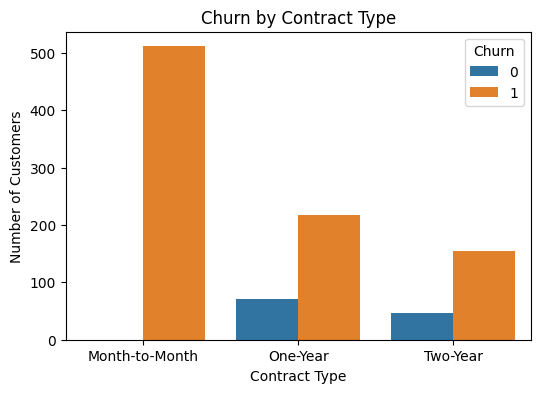

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='ContractType', hue='Churn', data=df)

plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')

plt.show()

### 2. Histogram — Monthly Charges Distribution

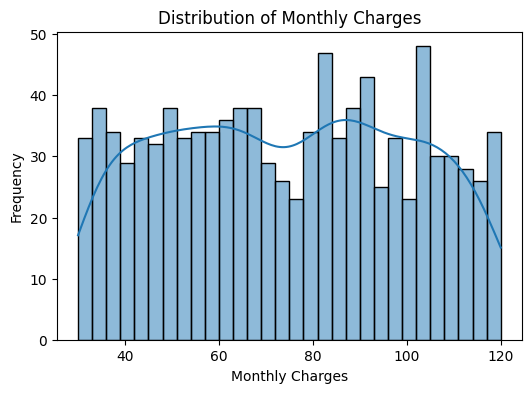

In [27]:
plt.figure(figsize=(6,4))
sns.histplot(df['MonthlyCharges'], bins=30, kde=True)

plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Frequency')

plt.show()

### 3. Box Plot — Tenure vs Churn

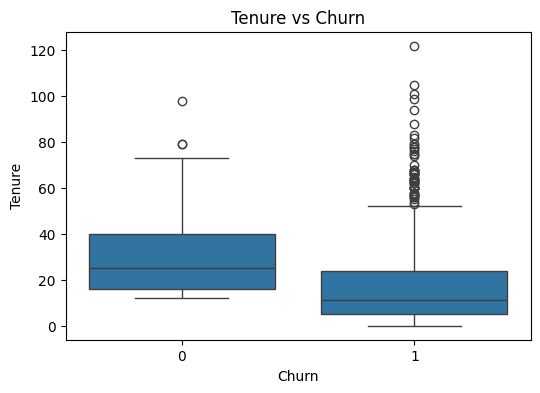

In [28]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='Tenure', data=df)

plt.title('Tenure vs Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure')

plt.show()

### 4. Line Plot — Average Tenure by Churn

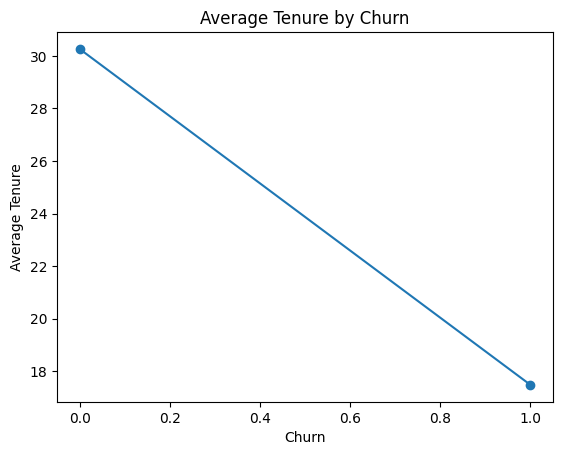

In [29]:
df.groupby('Churn')['Tenure'].mean().plot(kind='line', marker='o')

plt.title('Average Tenure by Churn')
plt.xlabel('Churn')
plt.ylabel('Average Tenure')

plt.show()